In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

In [3]:
ts = df["Sown_Extent_Total"]
ts.tail()

Date
2023-04-01    505076
2023-09-01    806673
2024-04-01    481316
2024-09-01    800463
2025-04-01    541422
Name: Sown_Extent_Total, dtype: int64

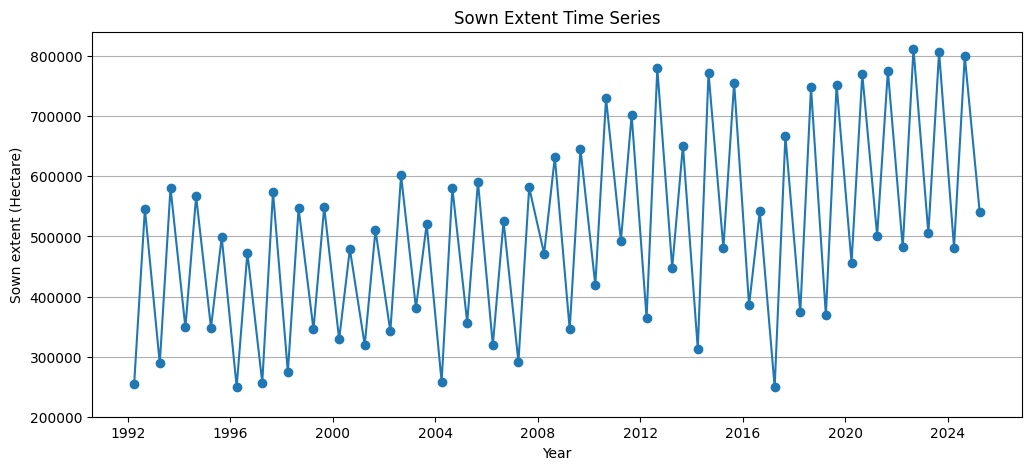

In [8]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o")

plt.title("Sown Extent Time Series")
plt.xlabel("Year")
plt.ylabel("Sown extent (Hectare)")
plt.grid(axis='y')
plt.ylim(200000,)
plt.show()

In [5]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -0.6556
    p-value   : 0.8579
    Critical 5%: -2.9147
    → ❌ NON-STATIONARY — differencing needed


np.float64(0.8579254016459419)

In [6]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=True,
                   test='adf', 
                   m=2, 
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)



Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[2] intercept   : AIC=1299.891, Time=0.11 sec
 ARIMA(0,0,0)(0,1,0)[2] intercept   : AIC=1307.910, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[2] intercept   : AIC=1298.611, Time=0.03 sec
 ARIMA(0,0,1)(0,1,1)[2] intercept   : AIC=1296.373, Time=0.03 sec
 ARIMA(0,0,0)(0,1,0)[2]             : AIC=1306.100, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[2] intercept   : AIC=1301.908, Time=0.02 sec
 ARIMA(0,0,1)(1,1,1)[2] intercept   : AIC=1298.205, Time=0.05 sec
 ARIMA(0,0,1)(0,1,2)[2] intercept   : AIC=1298.220, Time=0.04 sec
 ARIMA(0,0,1)(1,1,0)[2] intercept   : AIC=1297.839, Time=0.03 sec
 ARIMA(0,0,1)(1,1,2)[2] intercept   : AIC=1298.442, Time=0.09 sec
 ARIMA(0,0,0)(0,1,1)[2] intercept   : AIC=1303.447, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[2] intercept   : AIC=1297.627, Time=0.11 sec
 ARIMA(1,0,0)(0,1,1)[2] intercept   : AIC=1295.180, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[2] intercept   : AIC=1306.679, Time=0.02 sec
 ARIMA(1,0,0)(1,1,1)[2] intercept

In [10]:

# Generate a summary of the best model found
print(auto_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   53
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 2)   Log Likelihood                -644.010
Date:                             Sat, 23 May 2026   AIC                           1294.019
Time:                                     13:56:02   BIC                           1299.815
Sample:                                          0   HQIC                          1296.234
                                              - 53                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4100      0.182      2.253      0.024       0.053       0.767
ma.S.L2       -0.5525      

In [11]:
print(auto_model.fit(train))

 ARIMA(1,0,0)(0,1,1)[2]          


In [12]:
forecast = auto_model.predict(n_periods=len(test))
forecast

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    674539.272137
54    359052.232159
55    668508.367634
56    356579.770523
57    667494.744132
58    356164.220049
59    667324.382853
60    356094.377835
61    667295.749968
62    356082.639345
63    667290.937594
64    356080.666439
65    667290.128771
66    356080.334849
dtype: float64

In [13]:
forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])
forecast_df

,Prediction
Date,
2018-09-01,674539.27
2019-04-01,359052.23
2019-09-01,668508.37
2020-04-01,356579.77
2020-09-01,667494.74
2021-04-01,356164.22
2021-09-01,667324.38
2022-04-01,356094.38
2022-09-01,667295.75


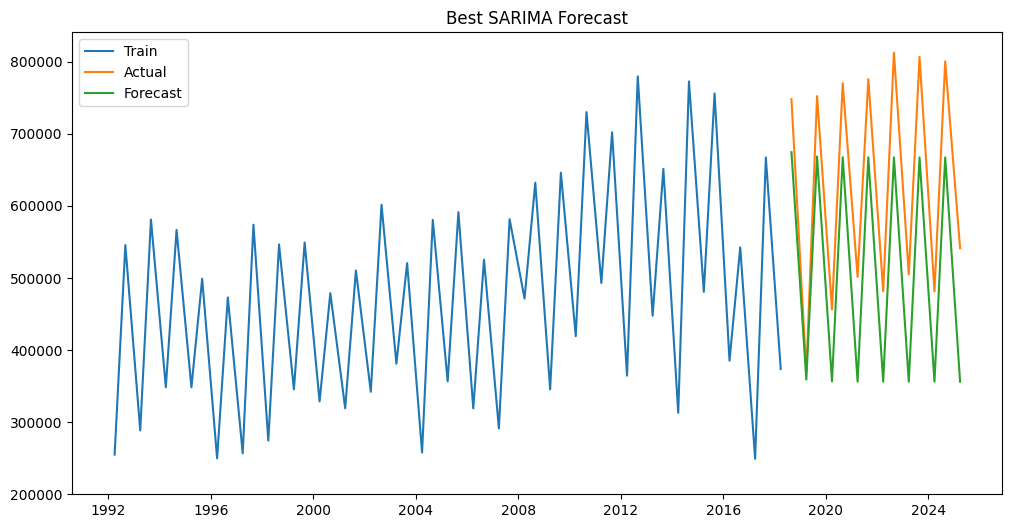

In [15]:
#Plot Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.legend()

plt.title("Best SARIMA Forecast")

plt.ylim(200000,)

plt.show()

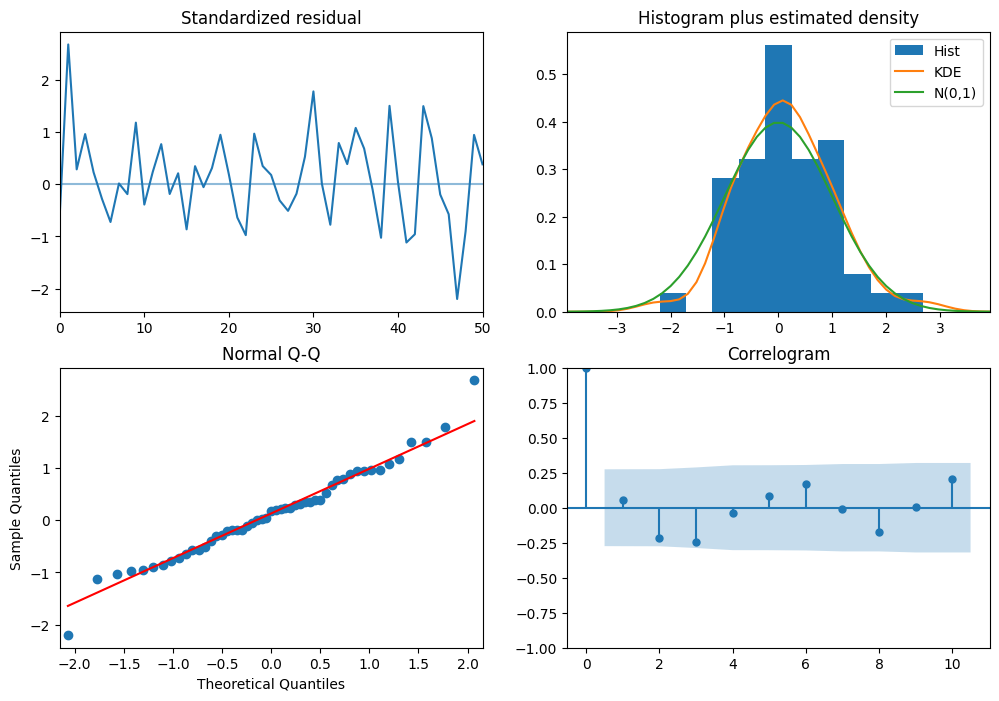

In [16]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [17]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 123103.06334586897
MAPE : 19.241887325781917
